In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path

# Downloading Data

In [2]:
# Configuration - Tickers and Paths
SNP = "^GSPC"
FTSE = "^FTSE"
tickers = ["AAPL", "JPM", "XOM", "PFE", "WMT", "HSBA.L", "BP.L", "TSCO.L", "AZN.L", "RR.L"]

# Paths
SAVE_PATH = Path("../data/raw")
INTERIM_PATH = Path("../data/interim")
PROCESSED_PATH = Path("../data/processed")
AUTO_ADJUST = True

# Ensure directories exist
for p in [SAVE_PATH, INTERIM_PATH, PROCESSED_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# Set the start, end and frequency for data collection
START = "2005-01-01"
END = "2025-09-30"
FREQ = "1mo"

In [3]:
# Download SNP500 data
snp_data = yf.download(
    SNP,
    start=START,
    end=END,
    interval=FREQ,
    auto_adjust=AUTO_ADJUST
)
snp_data.to_csv(f"{SAVE_PATH}/snp500_1mo_data.csv")
print(f"SNP500 downloaded: {len(snp_data)} rows")

# Download FTSE data
ftse_data = yf.download(
    FTSE,
    start=START,
    end=END,
    interval=FREQ,
    auto_adjust=AUTO_ADJUST
)
ftse_data.to_csv(f"{SAVE_PATH}/ftse_1mo_data.csv")
print(f"FTSE downloaded: {len(ftse_data)} rows")

# Download basket of stocks
basket_data = yf.download(
    tickers,
    start=START,
    end=END,
    interval=FREQ,
    auto_adjust=AUTO_ADJUST
)

# Convert basket to tidy format
ordered_list = []
for t in tickers:
    df_temp = basket_data.xs(t, level=1, axis=1).copy()
    df_temp["ticker"] = t
    df_temp = df_temp.reset_index().rename(columns=str.lower)
    ordered_list.append(df_temp)

tidy_equities_basket = pd.concat(ordered_list, ignore_index=True)
tidy_equities_basket.to_csv(f"{SAVE_PATH}/equities_basket_1mo_data.csv", index=False)
print(f"Equities basket downloaded: {len(tidy_equities_basket)} rows")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


SNP500 downloaded: 249 rows
FTSE downloaded: 249 rows


[*********************100%***********************]  10 of 10 completed

Equities basket downloaded: 2490 rows


# Cleaning datasets and saving 

In [4]:
# Clean Datasets
datasets = {
    "SNP500": snp_data,
    "FTSE": ftse_data,
    "Tidy Equities Basket": tidy_equities_basket
}

print("=== Null Values Check and Fix ===")
for name, df in datasets.items():
    null_count = df.isna().sum()
    total_nulls = null_count.sum()
    print(f"{name}: {total_nulls} null values")

    if total_nulls > 0:
        problematic_nulls = null_count[null_count > 0]
        for col, count in problematic_nulls.items():
            print(f"{col}: {count} nulls")

        if name == "Tidy Equities Basket":
            close_nulls = df['close'].isna().sum()
            if close_nulls > 0:
                before = len(df)
                df = df.dropna(subset=['close'])
                after = len(df)
                print(f"Dropped {before - after} rows with missing close data")

                datasets[name] = df
        else:
            close_nulls = df['Close'].isna().sum()
            if close_nulls > 0:
                before = len(df)
                df = df.dropna(subset=['Close'])
                after = len(df)
                print(f"Dropped {before - after} rows with missing close data")

                datasets[name] = df

    else:
        print("No Nulls found")


print("\n=== Duplicates Date Checks ===")
for name, df in datasets.items():
    if name == "Tidy Equities Basket":
        duplicate_dates = df.duplicated(subset = ['ticker', 'date']).sum()
        print(f"{name}: {duplicate_dates} duplicate dates across all tickers")

        if duplicate_dates > 0:
            before = len(df)
            df = df.drop_duplicates(subset=['ticker', 'date'], keep='last')
            after = len(df)
            print(f"Dropped {before-after} duplicated rows")

            datasets[name]= df
    else:
        duplicate_dates = df.index.duplicated().sum()
        print(f"{name}: {duplicate_dates} duplicate dates in index")

        if duplicate_dates > 0:
            before = len(df)
            df = df[df.index.duplicated(keep='last') == False]
            after = len(df)
            print(f"dropped {before-after} duplicate dates")

            datasets[name] = df

print("\n=== Chronological Dates Check ===")
for name, df in datasets.items():
    if name == 'Tidy Equities Basket':
        is_sorted = df.groupby('ticker')['date'].apply(lambda x: x.is_monotonic_increasing).all()
        print(f"{name}: Index sorted? {is_sorted}")

        if not is_sorted:
            df = df.sort_values(['ticker', 'date'])
            datasets[name] = df
            print(f"Fixed date sorting for: {name} ")
            # # Fix the data
            # tidy_equities_basket = tidy_equities_basket.sort_values(['ticker', 'date'])
            # # Resave the fixed version of data
            # tidy_equities_basket.to_csv(f"{INTERIM_PATH}/equities_basket_1mo_data.csv", index=False)
            # print(f"Fixed and resaved sorting for {name}")
    else:
        is_sorted = df.index.is_monotonic_increasing
        print(f"{name}: Index sorted? {is_sorted}")

        if not is_sorted:
            df = df.sort_index()
            datasets[name] = df
            print(f"Fixed date sorting for: {name}")


print("\n=== Month End Alignment ===")
for name, df in datasets.items():
    if name == "Tidy Equities Basket":
        # Convert date to datetime if not already
        df['date'] = pd.to_datetime(df['date'])

        # Group by ticker and resample to the end of the month
        resampled_list = []
        for ticker, group in df.groupby('ticker'):
            group_resampled = group.set_index('date').resample('ME').last()
            group_resampled['ticker'] = ticker
            resampled_list.append(group_resampled.reset_index())

        df = pd.concat(resampled_list, ignore_index = True)
        before_count = len(datasets[name])
        after_count = len(df)
        print(f"{name}: Resampled from {before_count} to {after_count} rows")
        datasets[name]= df
    else:
        before_count= len(df)
        df = df.resample('ME').last()
        after_count = len(df)
        print(f"{name}: Resampled from {before_count} to {after_count} rows")
        datasets[name] = df

print("\n=== Flatten MultiIndex Columns Before Saving ===")
# Flatten MultiIndex columns for indices (if they exist)
for name in ["SNP500", "FTSE"]:
    if isinstance(datasets[name].columns, pd.MultiIndex):
        datasets[name].columns = datasets[name].columns.get_level_values(0)
        print(f"  → Flattened columns for {name}")

print("\n=== Save Cleaned Data To Interim Folder ===")
datasets['SNP500'].to_csv(f"{INTERIM_PATH}/snp500_1mo_cleaned_data.csv")
datasets['FTSE'].to_csv(f"{INTERIM_PATH}/ftse_1mo_cleaned_data.csv")
datasets['Tidy Equities Basket'].to_csv(f"{INTERIM_PATH}/equities_1mo_cleaned_data.csv", index=False)
print("✓ Data saved successfully")

print("\n=== Final Summary ===")
for name, df in datasets.items():
    print(f"{name}: {len(df)} rows, {df.isna().sum().sum()} nulls")


=== Null Values Check and Fix ===
SNP500: 0 null values
No Nulls found
FTSE: 0 null values
No Nulls found
Tidy Equities Basket: 0 null values
No Nulls found

=== Duplicates Date Checks ===
SNP500: 0 duplicate dates in index
FTSE: 0 duplicate dates in index
Tidy Equities Basket: 0 duplicate dates across all tickers

=== Chronological Dates Check ===
SNP500: Index sorted? True
FTSE: Index sorted? True
Tidy Equities Basket: Index sorted? True

=== Month End Alignment ===
SNP500: Resampled from 249 to 249 rows
FTSE: Resampled from 249 to 249 rows
Tidy Equities Basket: Resampled from 2490 to 2490 rows

=== Flatten MultiIndex Columns Before Saving ===
  → Flattened columns for SNP500
  → Flattened columns for FTSE

=== Save Cleaned Data To Interim Folder ===
✓ Data saved successfully

=== Final Summary ===
SNP500: 249 rows, 0 nulls
FTSE: 249 rows, 0 nulls
Tidy Equities Basket: 2490 rows, 0 nulls


# Plots


Creating and Saving plots

Plotting:SNP500


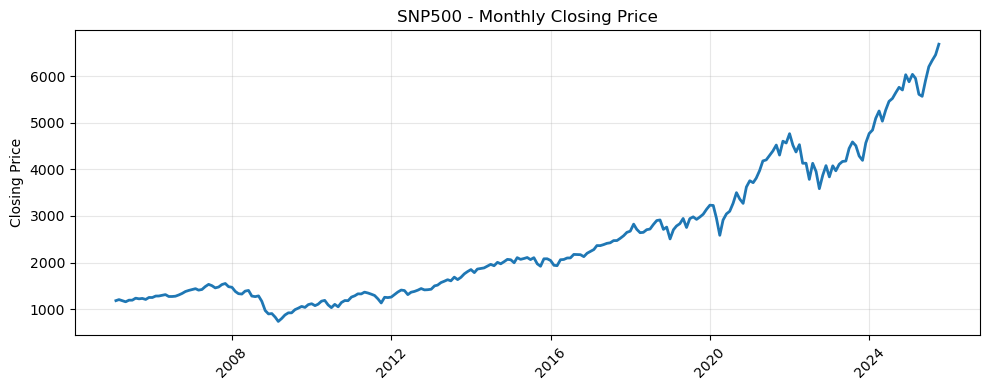


Plotting:FTSE


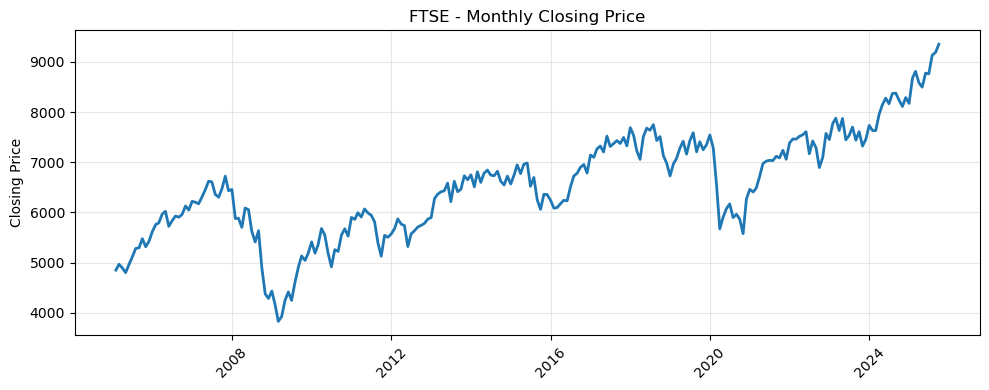


Plotting:Tidy Equities Basket


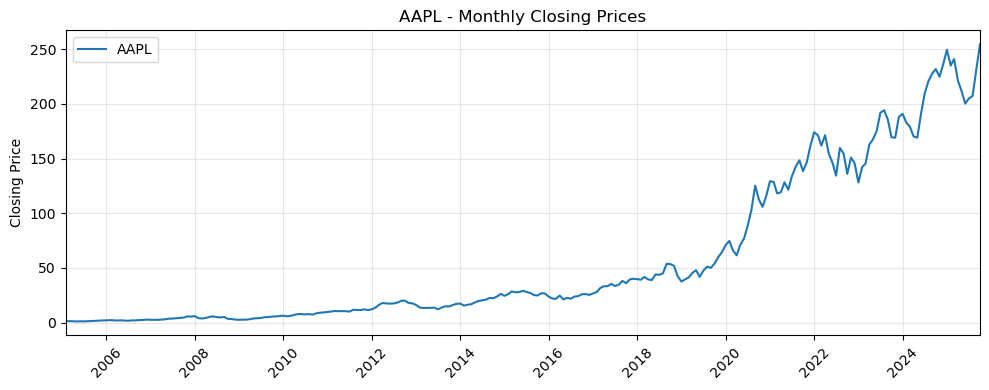

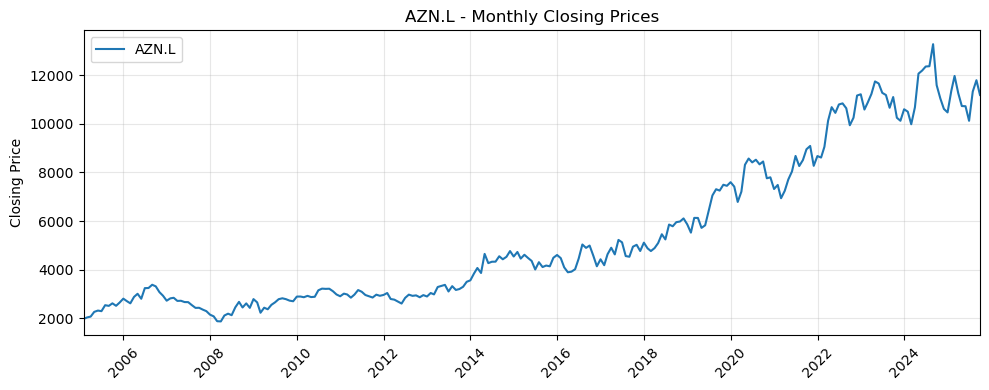

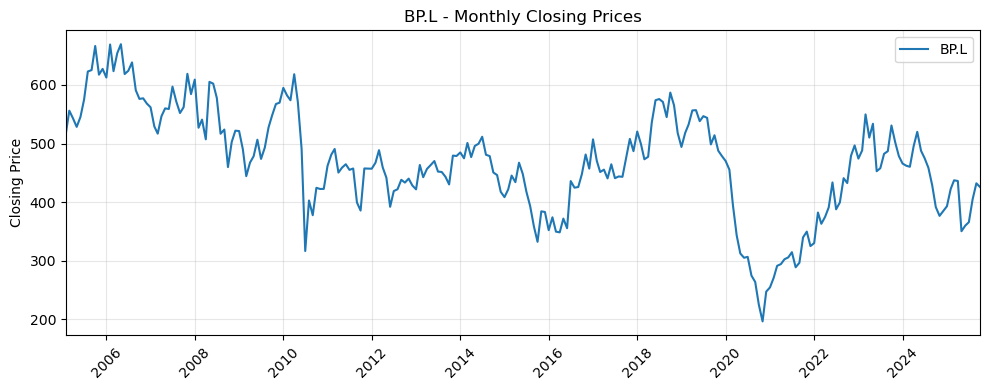

In [5]:
# Data clarity reports

REPORTS_PATH = Path('../reports/figures')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("\nCreating and Saving plots")
for name, df in datasets.items():
    print(f"\nPlotting:{name}")

    if name in ["SNP500", "FTSE"]:
        # Plot the close price
        plt.figure(figsize = (10,4))
        plt.plot(df.index, df['Close'], linewidth = 2)
        plt.title(f"{name} - Monthly Closing Price")
        plt.ylabel("Closing Price")
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        # plt.savefig(REPORTS_PATH / f"01_{name.lower()}_individual.png", dpi=150, bbox_inches='tight')
        plt.show()

    elif name == 'Tidy Equities Basket':
        sample_tickers = df['ticker'].unique()[:3]

        for ticker in sample_tickers:
            plt.figure(figsize=(10,4))
            stock_data = df[df['ticker'] == ticker]
            plt.plot(stock_data['date'],stock_data['close'], label=ticker)

            plt.xlim(df['date'].min(), df['date'].max())
            plt.title(f"{ticker} - Monthly Closing Prices")
            plt.ylabel('Closing Price')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            # plt.savefig(REPORTS_PATH / f"02_{ticker.lower()}.png", dpi=150, bbox_inches='tight')
            plt.show()


# Reasign the cleaned version of data to variable

In [6]:
SNP500 = datasets["SNP500"]
FTSE100 = datasets["FTSE"]
Tidy_Equities_Basket = datasets["Tidy Equities Basket"]

print(f"{SNP500}")
print(f"\n{FTSE100}")
print(f"\n{tidy_equities_basket}")

Price             Close         High          Low         Open        Volume
Date                                                                        
2005-01-31  1181.270020  1217.800049  1163.750000  1211.920044   31498800000
2005-02-28  1203.599976  1212.439941  1180.949951  1181.270020   29297410000
2005-03-31  1180.589966  1229.109985  1163.689941  1203.599976   39014150000
2005-04-30  1156.849976  1191.880005  1136.150024  1180.589966   43424270000
2005-05-31  1191.500000  1199.560059  1146.180054  1156.849976   39321990000
...                 ...          ...          ...          ...           ...
2025-05-31  5911.689941  5968.609863  5578.640137  5625.140137  105346260000
2025-06-30  6204.950195  6215.080078  5861.430176  5896.680176  106456300000
2025-07-31  6339.390137  6427.020020  6177.970215  6187.250000  114004890000
2025-08-31  6460.259766  6508.229980  6212.689941  6287.279785   99352030000
2025-09-30  6688.459961  6699.520020  6360.580078  6401.509766  114074610000